# scvi-tools workflow
## setup

In [1]:
import os
import tempfile

import scanpy as sc
import scvi
import seaborn as sns
import torch
import matplotlib.pyplot as plt

/home/inf-33-2025/Work/Nygen/Interview/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

Seed set to 0


Last run with scvi-tools version: 1.4.2


In [ ]:
# Modify aesthetics
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")
save_dir = tempfile.TemporaryDirectory()

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

## load and prepare data

In [ ]:
# Load the data
adata = scvi.data.heart_cell_atlas_subsampled(save_path=save_dir.name)
adata

INFO     Downloading file at /tmp/tmpgy3pz0pz/hca_subsampled_20k.h5ad                                              
Downloading...: 100%|██████████| 65714/65714.0 [00:00<00:00, 96442.48it/s]


AnnData object with n_obs × n_vars = 18641 × 26662
    obs: 'NRP', 'age_group', 'cell_source', 'cell_type', 'donor', 'gender', 'n_counts', 'n_genes', 'percent_mito', 'percent_ribo', 'region', 'sample', 'scrublet_score', 'source', 'type', 'version', 'cell_states', 'Used'
    var: 'gene_ids-Harvard-Nuclei', 'feature_types-Harvard-Nuclei', 'gene_ids-Sanger-Nuclei', 'feature_types-Sanger-Nuclei', 'gene_ids-Sanger-Cells', 'feature_types-Sanger-Cells', 'gene_ids-Sanger-CD45', 'feature_types-Sanger-CD45', 'n_counts'
    uns: 'cell_type_colors'

In [ ]:
# Remove lowly expressed genes
sc.pp.filter_genes(adata, min_counts=3)

In [ ]:
# Normalize the data without overwriting raw data
adata.layers["counts"] = adata.X.copy()  # preserve counts
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata  # freeze the state in `.raw`

Feature selection means reducing the number of genes (features generally) so the model has fewer inputs. Authors of scvi-tools recommend 1,000–10,000 HVGs

In [ ]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=1200,
    subset=True,
    layer="counts",
    flavor="seurat_v3",
    batch_key="cell_source",
)

The `setup` step informs scvi-tools of the anndata structure. For instance, if there are batches. In this case, we want to correct for cell source and donor, as well as the continuous covariates % mitochondria and % ribosome

In [8]:
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    categorical_covariate_keys=["cell_source", "donor"],
    continuous_covariate_keys=["percent_mito", "percent_ribo"],
)

## create and train model

In [ ]:
# Look at observations dataframe
adata.obs

,NRP,age_group,cell_source,cell_type,donor,gender,n_counts,n_genes,percent_mito,percent_ribo,region,sample,scrublet_score,source,type,version,cell_states,Used,_scvi_batch,_scvi_labels
AACTCCCCACGAGAGT-1-HCAHeart7844001,Yes,65-70,Sanger-CD45,Myeloid,D6,Male,1420.0,738,0.054930,0.064789,LA,HCAHeart7844001,0.113475,CD45+,DCD,V2,LYVE1+MØ1,Yes,0,0
ATAACGCAGAGCTGGT-1-HCAHeart7829979,No,70-75,Sanger-Nuclei,Ventricular_Cardiomyocyte,D4,Female,844.0,505,0.001185,0.001185,RV,HCAHeart7829979,0.085546,Nuclei,DCD,V2,vCM1,Yes,0,0
GTCAAGTCATGCCACG-1-HCAHeart7702879,Yes,60-65,Sanger-Nuclei,Fibroblast,D2,Male,1491.0,862,0.000000,0.005366,RA,HCAHeart7702879,0.197861,Nuclei,DCD,V2,FB2,Yes,0,0
GGTGATTCAAATGAGT-1-HCAHeart8102858,Yes,60-65,Sanger-CD45,Endothelial,D11,Female,2167.0,1115,0.064144,0.027227,LA,HCAHeart8102858,0.113475,CD45+,DCD,V3,EC10_CMC-like,Yes,0,0
AGAGAATTCTTAGCAG-1-HCAHeart8102863,Yes,60-65,Sanger-Cells,Endothelial,D11,Female,7334.0,2505,0.093537,0.040496,RA,HCAHeart8102863,0.132150,Cells,DCD,V3,EC5_art,Yes,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CGTCAGGCAAGGCTCC-1-HCAHeart7985087,No,55-60,Sanger-Nuclei,Ventricular_Cardiomyocyte,D3,Male,4478.0,2243,0.002233,0.001340,RV,HCAHeart7985087,0.185751,Nuclei,DBD,V2,vCM1,Yes,0,0
AGTCACAAGACGAGCT-1-H0035_RV,No,45-50,Harvard-Nuclei,Pericytes,H7,Female,967.0,630,0.002068,0.004137,RV,H0035_RV,0.081779,Nuclei,DBD,V3,PC1_vent,Yes,0,0
GGTGAAGGTTCCACAA-1-HCAHeart7844001,Yes,65-70,Sanger-CD45,Lymphoid,D6,Male,1599.0,619,0.041901,0.155722,LA,HCAHeart7844001,0.074830,CD45+,DCD,V2,CD4+T_tem,Yes,0,0
CAGCTAAGTACAGACG-1-HCAHeart7702876,Yes,60-65,Sanger-Nuclei,Atrial_Cardiomyocyte,D2,Male,3715.0,1523,0.000269,0.002423,LA,HCAHeart7702876,0.048649,Nuclei,DCD,V2,aCM3,Yes,0,0


In [9]:
model = scvi.model.SCVI(adata)
model

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [10]:
model.train(train_size=0.8, check_val_every_n_epoch=1)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/inf-33-2025/Work/Nygen/Interview/.venv/lib64/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/inf-33-2025/Work/Nygen/Interview/.venv/lib64/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=255` in the `DataLoader` to improve performance.
/home/inf-33-2025/Work/Nygen/Interview/.venv/lib64/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_co

Epoch 85/400:  21%|██        | 84/400 [51:29<2:31:50, 28.83s/it, v_num=1, train_loss=276]


Detected KeyboardInterrupt, attempting graceful shutdown ...


Exception raised during training. <class 'NameError'> 1


SystemExit: 1

/home/inf-33-2025/Work/Nygen/Interview/.venv/lib64/python3.12/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## save and load
the purpose of saving is to "freeze" the ANN weights, biases, and parameters used to initialize the model

In [ ]:
model_dir = os.path.join(save_dir.name, "scvi_model")
model.save(model_dir, overwrite=True)
# Load the model
# model = scvi.model.SCVI.load(model_dir, adata=adata)

INFO     File /var/folders/rj/58krw3q53619qt2rbck9wq740000gn/T/tmpd4ayllye/scvi_model/model.pt already downloaded  


/Users/otodreas/Desktop/Work/Nygen/Interview/.venv/lib/python3.12/site-packages/scvi/model/base/_base_model.py:862: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  _, _, device = parse_device_args(


## generate loss curves
access the losses in the `model.history` object and plot

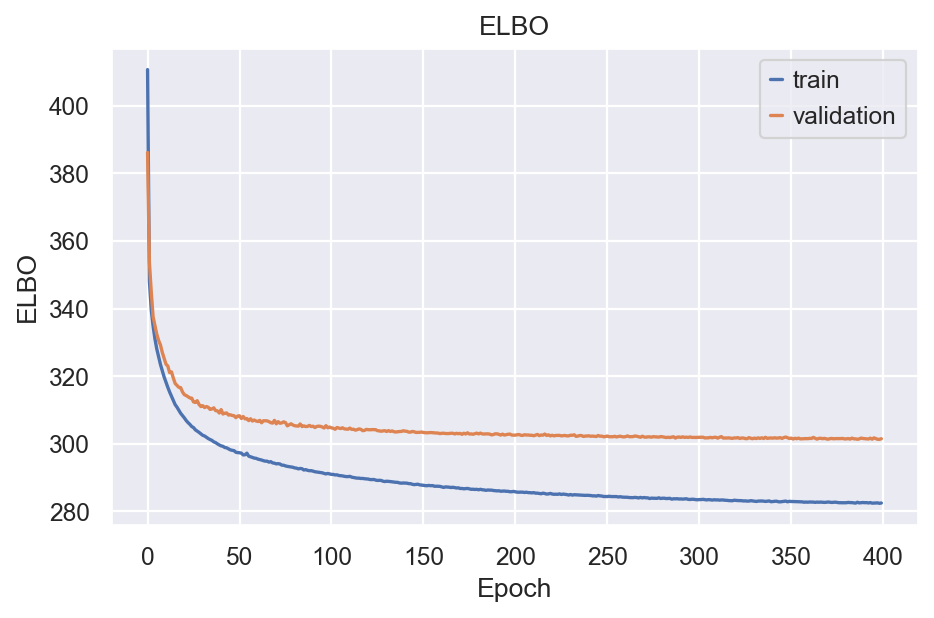

In [ ]:
hist = model.history

def plot_metric(train_key, val_key, title, ylabel):
    plt.figure(figsize=(6, 4))
    plt.plot(hist[train_key], label="train")
    plt.plot(hist[val_key], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Negative ELBO (Evidence lower bound)
if "elbo_train" in hist:
    plot_metric("elbo_train", "elbo_validation", "ELBO", "ELBO")

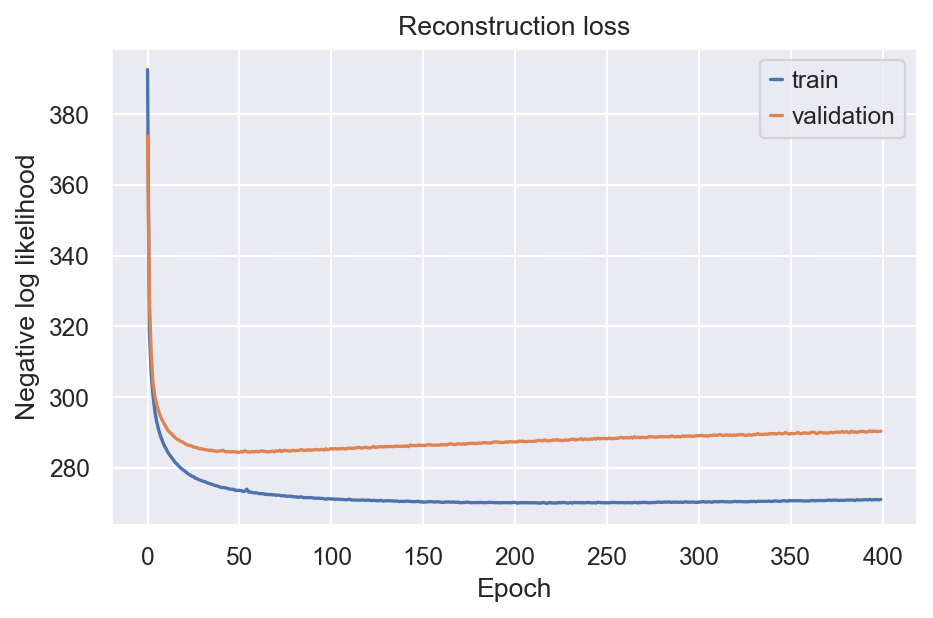

In [ ]:
# Reconstruction loss
plot_metric(
    "reconstruction_loss_train",
    "reconstruction_loss_validation",
    "Reconstruction loss",
    "Negative log likelihood",
)

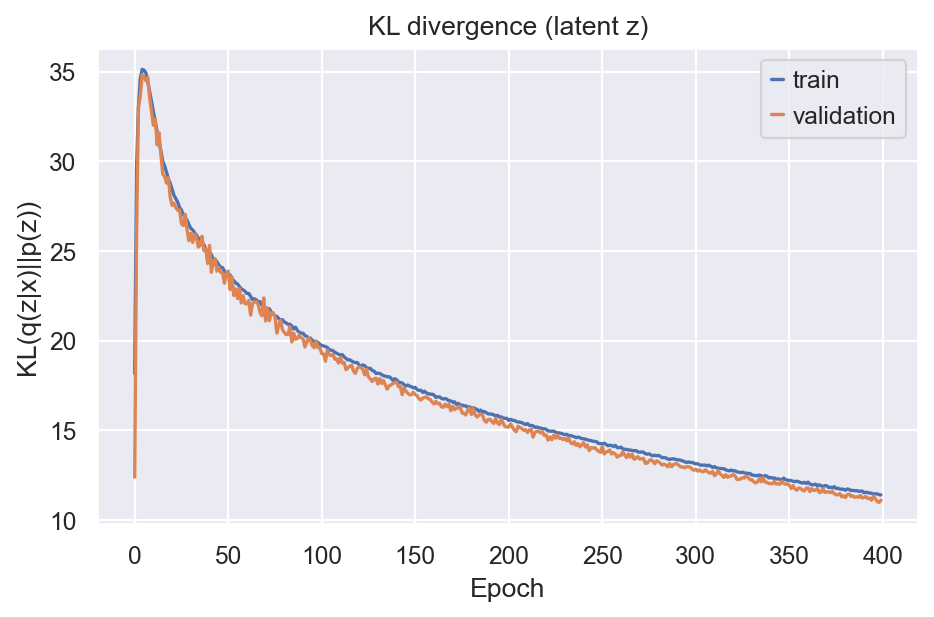

In [ ]:
# Local KL divergence
plot_metric(
    "kl_local_train", "kl_local_validation", "KL divergence (latent z)", "KL(q(z|x)||p(z))"
)

## obtaining model outputs

In [ ]:
SCVI_LATENT_KEY = "X_scVI"

latent = model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = latent
latent.shape

(18641, 10)

In [ ]:
adata_subset = adata[adata.obs.cell_type == "Fibroblast"]
latent_subset = model.get_latent_representation(adata_subset)
latent_subset.shape

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


(2446, 10)

In [ ]:
denoised = model.get_normalized_expression(adata_subset, library_size=1e4)
denoised.iloc[:5, :5]

,ISG15,TNFRSF18,VWA1,HES5,SPSB1
GTCAAGTCATGCCACG-1-HCAHeart7702879,1.001986,0.014438,1.468189,0.065635,3.661187
GAGTCATTCTCCGTGT-1-HCAHeart8287128,1.857320,0.009016,2.142300,0.131829,28.468678
CCTCTGATCGTGACAT-1-HCAHeart7702881,1.334203,0.022891,4.209394,0.068697,4.120722
CGCCATTCATCATCTT-1-H0035_apex,0.113215,0.045880,0.606629,0.055257,7.778178
TCGTAGAGTAGGACTG-1-H0015_septum,0.186776,0.012788,0.410557,0.069813,7.895931


## vizualisation without batch correction
below, objects produced by scvi-tools are fed into a scanpy workflow

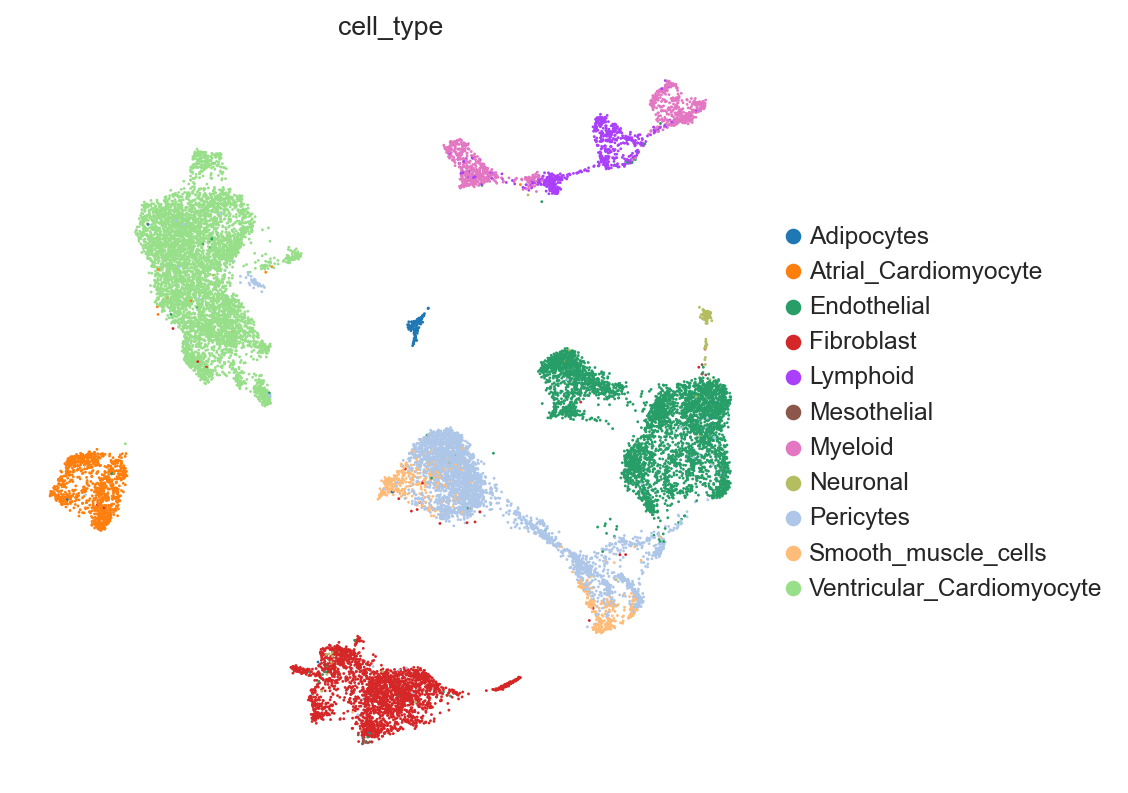

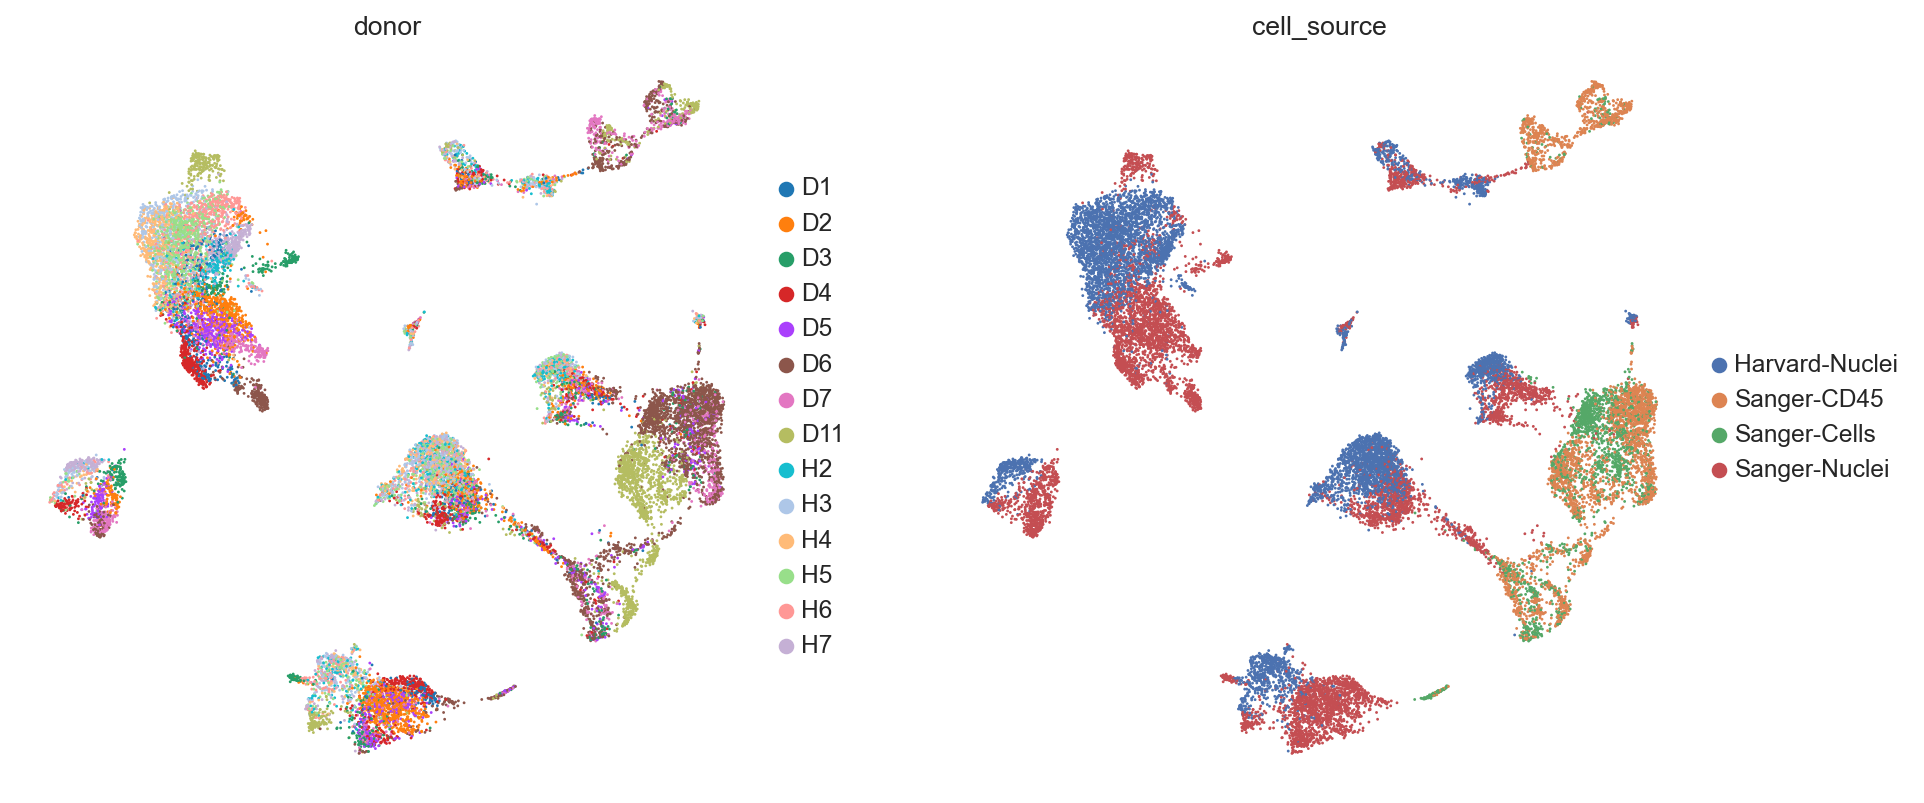

In [ ]:
# run PCA then generate UMAP plots
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=20)
sc.tl.umap(adata, min_dist=0.3)

sc.pl.umap(
    adata,
    color=["cell_type"],
    frameon=False,
)
sc.pl.umap(
    adata,
    color=["donor", "cell_source"],
    ncols=2,
    frameon=False,
)

## vizualisation with batch correction (scVI)
the difference here is that we use the scVI latent space to generate UMAP

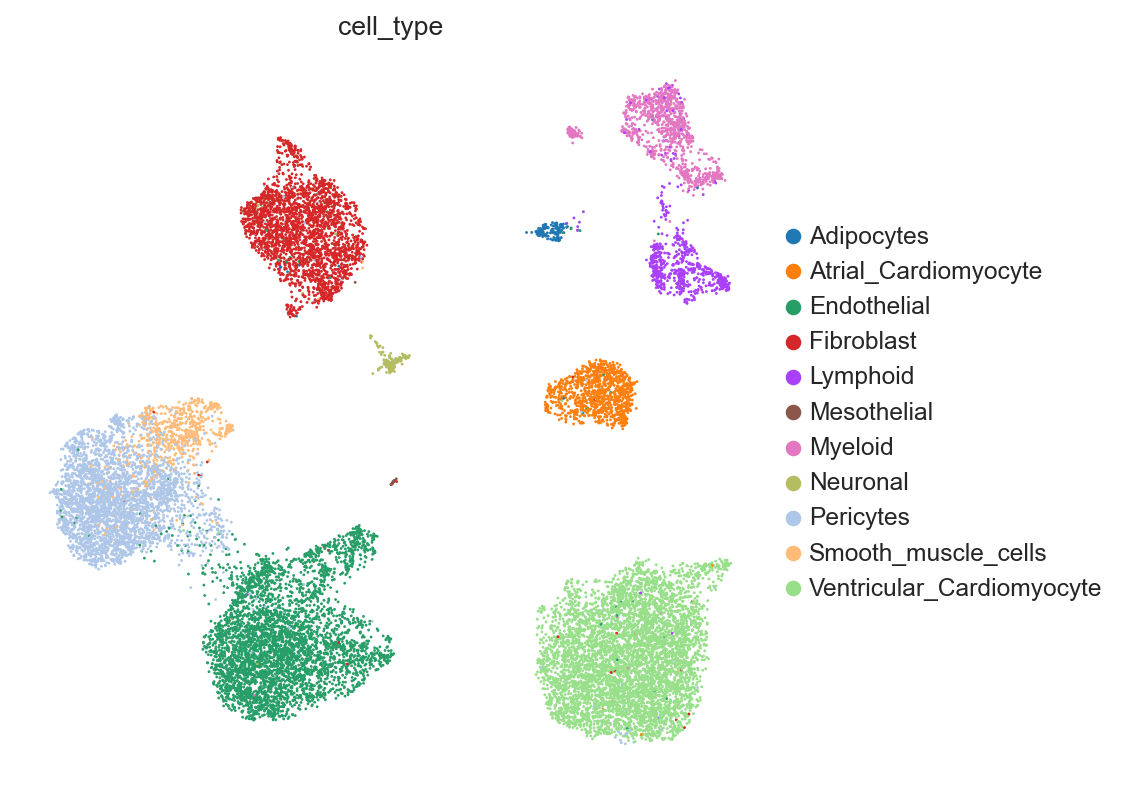

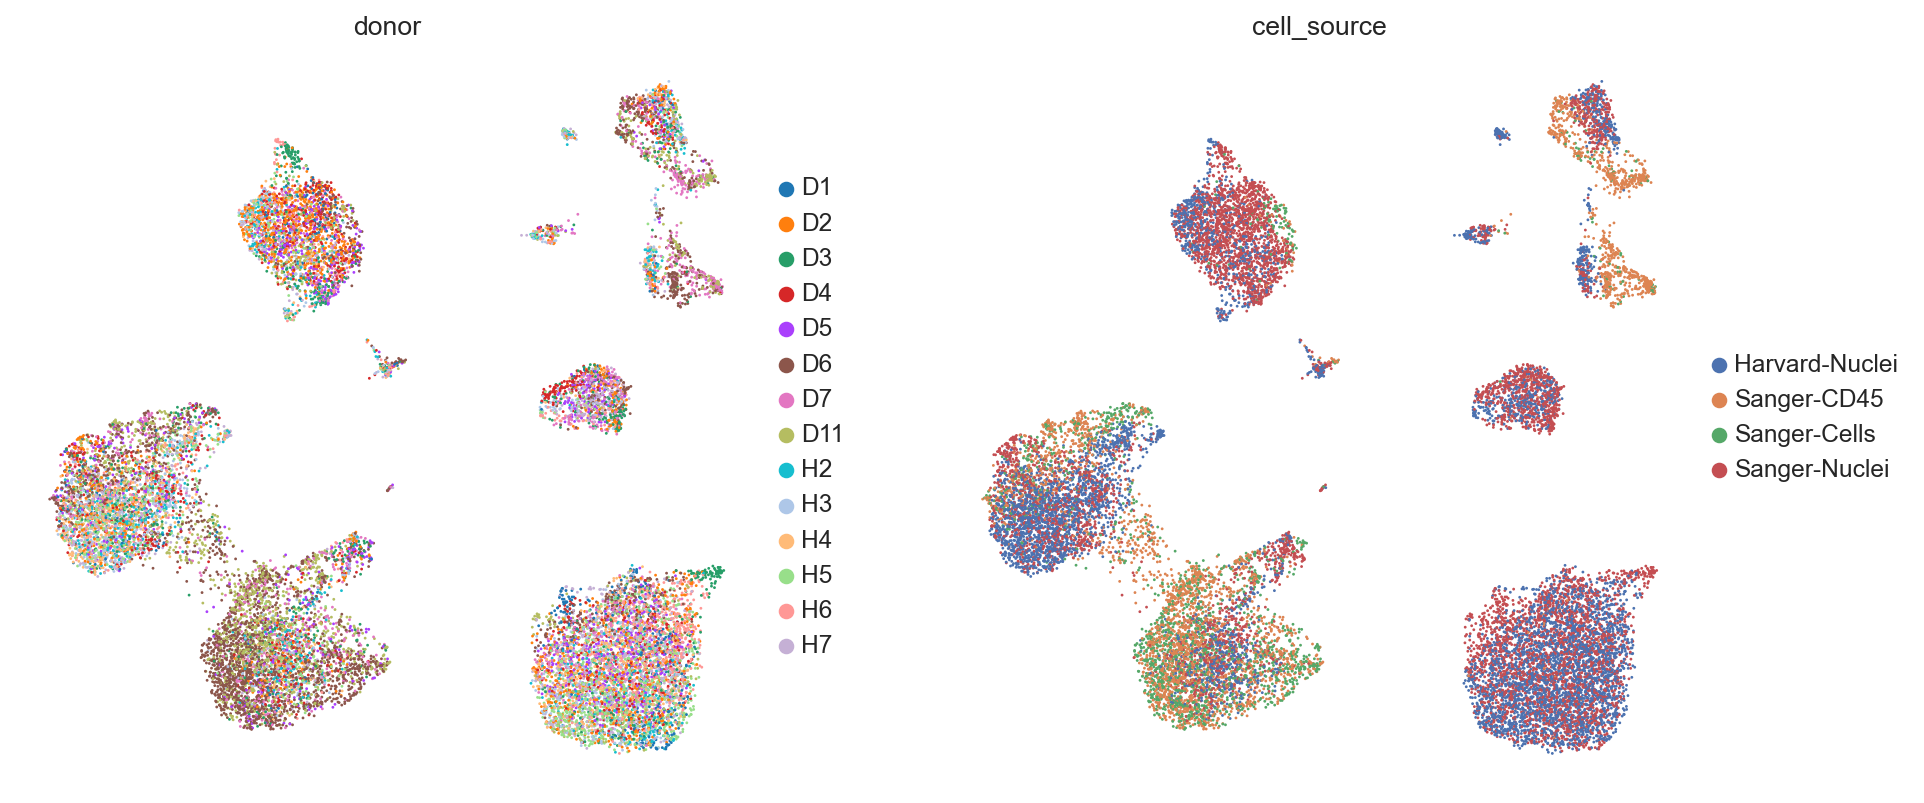

In [ ]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata, min_dist=0.3)

sc.pl.umap(
    adata,
    color=["cell_type"],
    frameon=False,
)
sc.pl.umap(
    adata,
    color=["donor", "cell_source"],
    ncols=2,
    frameon=False,
)

## clustering on the scVI latent space
this is differential expression analysis. 